In [ ]:
import pandas as pd

# definition des types pour economiser la RAM
dtypes = {
    "iu_ac": "category",
    "libelle": "category",
    "q": "float32",
    "k": "float32",
    "etat_trafic": "category",
    "etat_barre": "category",
    "iu_nd_amont": "category",
    "libelle_nd_amont": "category",
    "iu_nd_aval": "category",
    "libelle_nd_aval": "category",
}

chunks = []
# Chargement par chunks de 50 000 lignes
for chunk in pd.read_csv(
    "../data/raw/comptages.csv",
    sep=";",
    dtype=dtypes,
    chunksize=50_000,
    parse_dates=["t_1h"]
):
    chunks.append(chunk)

df = pd.concat(chunks, ignore_index=True)
print("Données chargées avec succès !")

Données chargées avec succès !


In [2]:
# Dimensions du jeu de données
print(f"Dimensions : {df.shape[0]:,} lignes × {df.shape[1]} colonnes\n")

# Types des colonnes
print("--- Types de colonnes ---")
print(df.dtypes)

# Part de valeurs manquantes par colonne (en %)
print("\n--- Part de valeurs manquantes (%) ---")
missing_pct = (df.isna().sum() / len(df)) * 100
print(missing_pct.round(2).astype(str) + " %")

Dimensions : 148,376 lignes × 11 colonnes

--- Types de colonnes ---
iu_ac                          category
libelle                        category
t_1h                datetime64[us, UTC]
q                               float32
k                               float32
etat_trafic                    category
iu_nd_amont                    category
libelle_nd_amont               category
iu_nd_aval                     category
libelle_nd_aval                category
etat_barre                     category
dtype: object

--- Part de valeurs manquantes (%) ---
iu_ac                 0.0 %
libelle               0.0 %
t_1h                  0.0 %
q                   19.83 %
k                   20.16 %
etat_trafic           0.0 %
iu_nd_amont           0.0 %
libelle_nd_amont      0.0 %
iu_nd_aval            0.0 %
libelle_nd_aval       0.0 %
etat_barre            0.0 %
dtype: str


Graphique 1 : Distribution du débit horaire (q) par axe

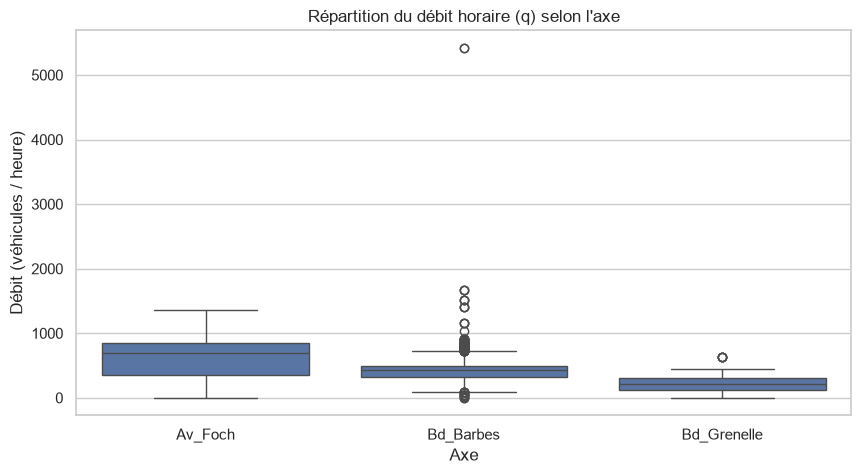

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="libelle", y="q")
plt.title("Répartition du débit horaire (q) selon l'axe")
plt.xlabel("Axe")
plt.ylabel("Débit (véhicules / heure)")
plt.show()

Interpretation : l'Avenue Foch est la voie qui a régulièrement le plus gros volume de circulation au quotidien , tandis que le Boulevard de Grenelle est plus calme et moins fréquenté parmi les trois. Le trafic moyen au niveau du Boulevard Barbès est plutôt bas mais instable car on a des pics de circulation par moment.

Graphique 2 : Taux d'occupation moyen (k) par état du trafic

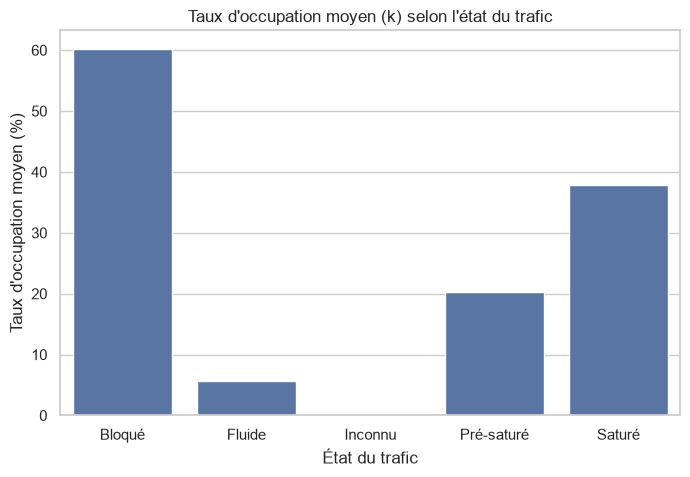

In [4]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="etat_trafic", y="k", estimator="mean", errorbar=None)
plt.title("Taux d'occupation moyen (k) selon l'état du trafic")
plt.xlabel("État du trafic")
plt.ylabel("Taux d'occupation moyen (%)")
plt.show()

Interpretation : Ce graphique mesure a quel point la route est occupee c'est a dire l'espace que les voitures occupent sur la chaussee. C'est logique  car quand c'est Fluide les voitures roulent et ne prennent presque pas de place (environ 5 % d'occupation). Dès que ça devient Pré-saturé puis Saturé, l'espace commence à se remplir (38 %), et quand c'est totalement  Bloqué, le taux monte à 60 %.

Graphique 3 : Profil horaire moyen du débit (q)

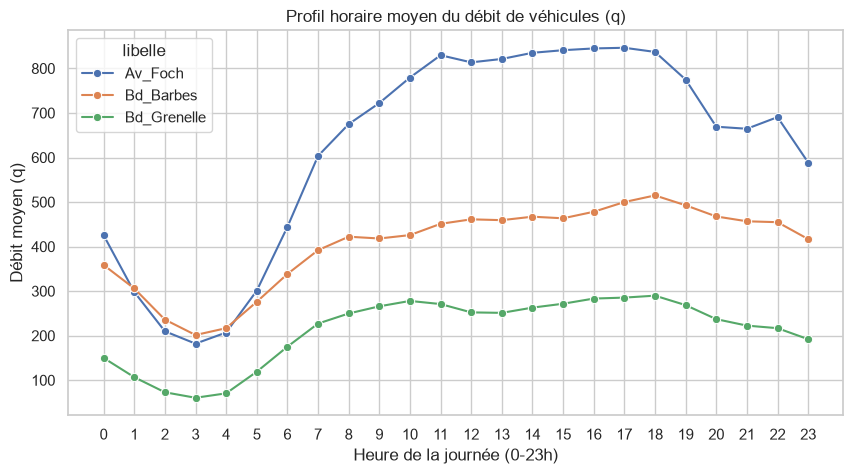

In [5]:
df["heure"] = df["t_1h"].dt.hour
df_hourly = (
    df.groupby(["heure", "libelle"], observed=True)["q"].mean().reset_index()
)

plt.figure(figsize=(10, 5))
sns.lineplot(data=df_hourly, x="heure", y="q", hue="libelle", marker="o")
plt.title("Profil horaire moyen du débit de véhicules (q)")
plt.xlabel("Heure de la journée (0-23h)")
plt.ylabel("Débit moyen (q)")
plt.xticks(range(0, 24))
plt.show()

Interpretation : Ce graphique nous montre le rythme de la journée. Ça prouve que tout le monde vit au même moment carl le trafic est quasiment mort la nuit, mais explose le matin quand tout le monde au boulot, a l'ecole, etc..., ça se calme un peu l'après-midi, et ça remonte à nouveau le soir quand tout le monde rentre chez lui. Nous pouvons remarquer que l'Avenue Foch est beaucoup plus empruntee, suivie du Boulevard de Barbes.